MNIST Handwritten Digit Classification using Neural Networks

Importing the Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf

tf.random.set_seed(3)

from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix



Loading the MNIST data from Keras Datasets

In [2]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

In [3]:
type(x_train)

numpy.ndarray

In [4]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

Training Data = 60000 Images , 
Test Data = 10000 Images  

Image Dimension --> 28x28
    
Grayscale Image --> 1 Channel

In [5]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [6]:
print(x_train[10].shape)

(28, 28)


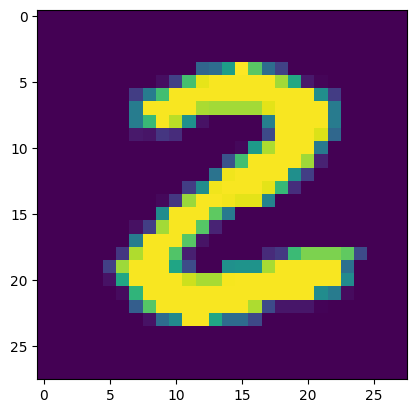

2


In [7]:
plt.imshow(x_train[25])
plt.show()

print(y_train[25])

Image Labels

In [8]:
y_train.shape , y_test.shape

((60000,), (10000,))

In [9]:
print(np.unique(y_train ))

print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


Scaling the Values

In [10]:
x_train = x_train / 255

x_test = x_test / 255

In [11]:
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

Setting up the layers of the Neural Network

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation="relu"),
    keras.layers.Dense(50 , activation="relu"),
    keras.layers.Dense(10, activation="sigmoid")
])

c:\Users\Rajasekar\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Compiling the Neural Network

In [13]:
model.compile(optimizer="adam", 
              loss="sparse_categorical_crossentropy", 
              metrics=["accuracy"]
)

Training the Neural Network

In [14]:
model.fit(x_train , y_train , epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9126 - loss: 0.2984
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9604 - loss: 0.1339
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9708 - loss: 0.0978
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9768 - loss: 0.0770
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9809 - loss: 0.0625
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9839 - loss: 0.0521
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0444
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9886 - loss: 0.0382
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9897 - loss: 0.0337
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9908 - loss: 0.0291


Accuracy on Test Data

In [15]:
loss , accuracy = model.evaluate(x_test , y_test)

print("Accuracy on Training Data : ",0.9908)

print("Accuracy on Test Data : ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9702 - loss: 0.1228
Accuracy on Training Data :  0.9908
Accuracy on Test Data :  0.9702000021934509


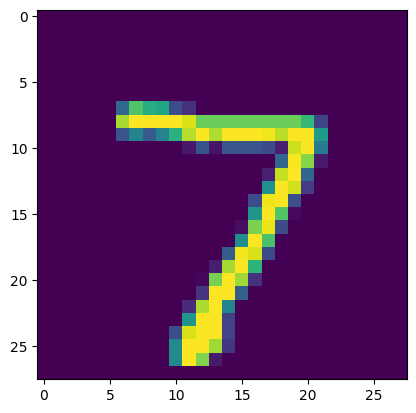

In [16]:
plt.imshow(x_test[0])
plt.show()

In [17]:
print(y_test[0])

7


In [18]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [19]:
y_pred.shape

(10000, 10)

In [20]:
print(y_pred[0])

[1.3819621e-05 1.5148866e-07 1.0303147e-03 1.1971835e-01 5.7870666e-06
 1.1772310e-05 8.2713664e-13 9.9999714e-01 1.1678237e-03 3.1804241e-02]


Converting the Prediction Probabilities to class label

In [21]:
label_for_first_img = np.argmax(y_pred[0])

print(label_for_first_img)

7


Converting the prediction probabilities to class labels for all test data points 

In [22]:
y_pred_labels = [np.argmax(i) for i in y_pred]

print(y_pred_labels)

[7, 2, 1, 0, 4, 1, 4, 9, 8, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5, 4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 5, 1, 2, 4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 8, 3, 7, 4, 6, 4, 3, 0, 7, 0, 2, 9, 1, 7, 3, 2, 9, 7, 7, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 9, 3, 1, 4, 1, 7, 6, 9, 6, 0, 5, 4, 9, 9, 2, 1, 9, 4, 8, 7, 3, 9, 7, 9, 4, 4, 9, 2, 5, 4, 7, 6, 4, 9, 9, 5, 8, 5, 6, 6, 5, 7, 8, 1, 0, 1, 6, 4, 6, 7, 3, 1, 7, 1, 8, 2, 0, 9, 9, 9, 5, 5, 1, 5, 6, 0, 3, 4, 4, 6, 5, 4, 6, 5, 4, 5, 1, 4, 4, 7, 2, 3, 2, 7, 1, 8, 1, 8, 1, 8, 5, 0, 8, 9, 2, 5, 0, 1, 1, 1, 0, 9, 0, 4, 1, 6, 4, 2, 3, 6, 1, 1, 1, 3, 9, 5, 2, 9, 4, 5, 9, 3, 9, 0, 3, 5, 5, 5, 7, 2, 2, 7, 1, 2, 8, 4, 1, 7, 3, 3, 8, 8, 7, 9, 2, 2, 4, 1, 5, 9, 8, 7, 2, 3, 0, 6, 4, 2, 4, 1, 9, 5, 7, 7, 2, 8, 2, 0, 8, 5, 7, 7, 9, 1, 8, 1, 8, 0, 3, 0, 1, 9, 9, 4, 1, 8, 2, 1, 2, 9, 7, 5, 9, 2, 6, 4, 1, 5, 4, 2, 9, 2, 0, 4, 0, 0, 2, 8, 4, 7, 1, 2, 4, 0, 2, 7, 4, 3, 3, 0, 0, 3, 1, 9, 6, 5, 2, 5, 9, 7, 9, 3, 0, 4, 2, 0, 7, 1, 1, 2, 1, 

y_test --> True labels

 y_pred_labels --> Predicted labels

Confusion Matrix

In [23]:
conf_mat = confusion_matrix(y_test , y_pred_labels)

print(conf_mat)

tf.Tensor(
[[ 955    1    2    1    4    1    2    0    1   13]
 [   0 1122    0    3    1    1    2    1    5    0]
 [   4    1  996    5    2    0    1   11   11    1]
 [   0    0    3  981    4    2    0    5    8    7]
 [   0    0    3    1  965    0    3    1    2    7]
 [   4    0    0   10    3  850    4    2   14    5]
 [   4    3    6    1    6    5  925    1    4    3]
 [   1    3    5    3    4    0    0  995    5   12]
 [   5    0    3    3   10    2    2    3  939    7]
 [   1    2    0    5   21    2    0    3    1  974]], shape=(10, 10), dtype=int32)


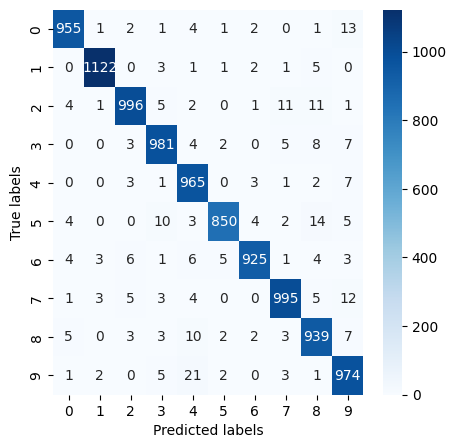

In [24]:
plt.figure(figsize=(5,5))
sns.heatmap(conf_mat , annot=True , fmt="d", cmap="Blues")
plt.ylabel("True labels")
plt.xlabel("Predicted labels")
plt.show()

Building a Predictive System

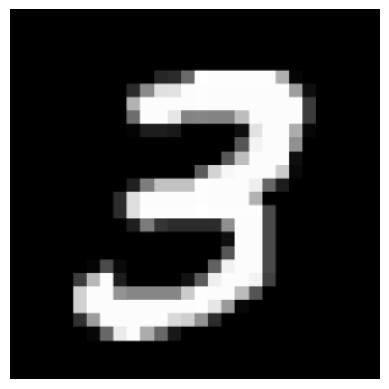

In [25]:
input_image_path = r"C:\Users\Rajasekar\Downloads\MNIST_digit.png"

input_img = cv2.imread(input_image_path)

input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)

plt.imshow(input_img)
plt.axis("off")
plt.show()

In [26]:
input_img.shape

(318, 318, 3)

In [27]:
gray_scale = cv2.cvtColor(input_img , cv2.COLOR_RGB2GRAY)

In [28]:
gray_scale.shape

(318, 318)

In [29]:
input_img_resize = cv2.resize(gray_scale , (28,28))

In [30]:
input_img_resize.shape

(28, 28)

In [ ]:
cv2.imshow("Input Image" , input_img_resize)

In [34]:
input_img_resize = input_img_resize / 255

In [35]:
img_reshape = np.reshape(input_img_resize , (1,28,28))

In [36]:
input_pred = model.predict(img_reshape)

print(input_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
[[1.2668340e-11 1.4436664e-06 1.3355909e-06 1.0000000e+00 1.8706957e-07
  4.9675480e-05 2.8680032e-22 2.1301739e-07 2.1239777e-01 9.3105245e-01]]


In [40]:
input_pred_label = np.argmax(input_pred)

print("---------- Prediction Result ----------")
print("The Handwritten Image is : ", input_pred_label)

---------- Prediction Result ----------
The Handwritten Image is :  3
